<a href="https://colab.research.google.com/github/soeharo/Mi-primer-repositorio/blob/main/apuntes_de_Spark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pyspark

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, sum, count, when, concat, substring, date_add, lit
from pyspark.sql.types import StructType, StructField, StringType, FloatType, DateType, IntegerType
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, rank
from pyspark.sql.functions import expr
from pyspark.sql.functions import udf

In [ ]:
spark = SparkSession.builder.appName("Ejemplo Spark").getOrCreate()

In [ ]:
data = [("Alice", 25), ("Bob", 32), ("Charlie", 25), ("David", 32), ("Bob", 31), ("David", 23), ("Charlie", 41)]


In [ ]:
schema = StructType([
    StructField("nombre", StringType(), True),
    StructField("edad", IntegerType(), True)
])

df = spark.createDataFrame(data, schema)

transformed_df = df.withColumn("edadmas2", col("edad") + 2)

transformed_df.show()

+-------+----+--------+
| nombre|edad|edadmas2|
+-------+----+--------+
|  Alice|  25|      27|
|    Bob|  32|      34|
|Charlie|  25|      27|
|  David|  32|      34|
|    Bob|  31|      33|
|  David|  23|      25|
|Charlie|  41|      43|
+-------+----+--------+



In [ ]:
filtered_df = df.filter((col("edad") >= 25) & (col("edad") <= 35))

filtered_df.show()
#

+-------+----+
| nombre|edad|
+-------+----+
|  Alice|  25|
|    Bob|  32|
|Charlie|  25|
|  David|  32|
|    Bob|  31|
+-------+----+



In [ ]:
grouped_df = df.groupBy("nombre").agg(avg("edad").alias("edad_promedio"))

grouped_df.show()
#

+-------+-------------+
| nombre|edad_promedio|
+-------+-------------+
|Charlie|         33.0|
|    Bob|         31.5|
|  Alice|         25.0|
|  David|         27.5|
+-------+-------------+



In [ ]:
data1 = [("Alice", 25), ("Bob", 32), ("Charlie", 24), ("David", 47), ("Bob", 31), ("David", 23), ("Charlie", 41)]
data2 = [("Alice", 42), ("Bob", 23), ("Charlie", 54), ("David", 26), ("Bob", 41), ("David", 20), ("Charlie", 48)]

schema = StructType([
    StructField("nombre", StringType(), True),
    StructField("edad", IntegerType(), True)
])

df1 = spark.createDataFrame(data1, schema)
df2 = spark.createDataFrame(data2, schema)

joined_df = df1.alias("df1").join(df2.alias("df2"), on="nombre", how="inner")
joined_df.show()
#

+-------+----+----+
| nombre|edad|edad|
+-------+----+----+
|  Alice|  25|  42|
|    Bob|  32|  23|
|    Bob|  32|  41|
|    Bob|  31|  23|
|    Bob|  31|  41|
|Charlie|  24|  54|
|Charlie|  24|  48|
|Charlie|  41|  54|
|Charlie|  41|  48|
|  David|  47|  26|
|  David|  47|  20|
|  David|  23|  26|
|  David|  23|  20|
+-------+----+----+



In [ ]:
unioned_df = df1.union(df2)

unioned_df.show()


+-------+----+
| nombre|edad|
+-------+----+
|  Alice|  25|
|    Bob|  32|
|Charlie|  24|
|  David|  47|
|    Bob|  31|
|  David|  23|
|Charlie|  41|
|  Alice|  42|
|    Bob|  23|
|Charlie|  54|
|  David|  26|
|    Bob|  41|
|  David|  20|
|Charlie|  48|
+-------+----+



In [ ]:
window_spec = Window.partitionBy("nombre").orderBy("edad")

df_with_rank = df.withColumn("rank", rank().over(window_spec))

df_with_rank.show()


+-------+----+----+
| nombre|edad|rank|
+-------+----+----+
|  Alice|  25|   1|
|    Bob|  31|   1|
|    Bob|  32|   2|
|Charlie|  25|   1|
|Charlie|  41|   2|
|  David|  23|   1|
|  David|  32|   2|
+-------+----+----+



In [ ]:
window_spec = Window.orderBy(col("edad"))
ranked_df = df.withColumn("rank", rank().over(window_spec))
row_numbered = df.withColumn("row_number", row_number().over(window_spec))
ranked_df.show()

row_numbered.show()

#

+-------+----+----+
| nombre|edad|rank|
+-------+----+----+
|  David|  23|   1|
|  Alice|  25|   2|
|Charlie|  25|   2|
|    Bob|  31|   4|
|    Bob|  32|   5|
|  David|  32|   5|
|Charlie|  41|   7|
+-------+----+----+

+-------+----+----------+
| nombre|edad|row_number|
+-------+----+----------+
|  David|  23|         1|
|  Alice|  25|         2|
|Charlie|  25|         3|
|    Bob|  31|         4|
|    Bob|  32|         5|
|  David|  32|         6|
|Charlie|  41|         7|
+-------+----+----------+



In [ ]:
data = [("Alice", 25), ("Bob", None), ("Charlie", 25), ("David", None), ("Bob", 25), ("David", 23), ("Charlie", 41)]

df = spark.createDataFrame(data, schema)
df.show()

+-------+----+
| nombre|edad|
+-------+----+
|  Alice|  25|
|    Bob|NULL|
|Charlie|  25|
|  David|NULL|
|    Bob|  25|
|  David|  23|
|Charlie|  41|
+-------+----+



In [ ]:
filled_df = df.fillna({"edad": 26})
filled_df.show()

+-------+----+
| nombre|edad|
+-------+----+
|  Alice|  25|
|    Bob|  26|
|Charlie|  25|
|  David|  26|
|    Bob|  25|
|  David|  23|
|Charlie|  41|
+-------+----+



In [ ]:
# llenado de vaciós con la mediana
from pyspark.sql.functions import avg

median_edad = df.approxQuantile("edad", [0.5], 0.01)[0]
filled_median_df = df.fillna({"edad": median_edad})

# llenado de vaciós con la media


mean_edad = df.agg(avg("edad")).head()[0]
filled_mean_df = df.fillna({"edad": mean_edad})

filled_median_df.show()
filled_mean_df.show()

+-------+----+
| nombre|edad|
+-------+----+
|  Alice|  25|
|    Bob|  25|
|Charlie|  25|
|  David|  25|
|    Bob|  25|
|  David|  23|
|Charlie|  41|
+-------+----+

+-------+----+
| nombre|edad|
+-------+----+
|  Alice|  25|
|    Bob|  27|
|Charlie|  25|
|  David|  27|
|    Bob|  25|
|  David|  23|
|Charlie|  41|
+-------+----+



In [ ]:
data = [("Alice", "Smith"), ("Bob", "Johnson"), ("Charlie", "Williams"), ("David", "Brown")]

df = spark.createDataFrame(data, ["nombre", "apellido"])

df.show()

+-------+--------+
| nombre|apellido|
+-------+--------+
|  Alice|   Smith|
|    Bob| Johnson|
|Charlie|Williams|
|  David|   Brown|
+-------+--------+



In [ ]:
concatenated_df = df.withColumn("Nombre completo", concat(col("nombre"), lit(" "), col("apellido")))

concatenated_df.show()

+-------+--------+----------------+
| nombre|apellido| Nombre completo|
+-------+--------+----------------+
|  Alice|   Smith|     Alice Smith|
|    Bob| Johnson|     Bob Johnson|
|Charlie|Williams|Charlie Williams|
|  David|   Brown|     David Brown|
+-------+--------+----------------+



In [ ]:
substring_df = df.withColumn("Primeras letras", substring(col("nombre"), 1, 3))

substring_df.show()

+-------+--------+---------------+
| nombre|apellido|Primeras letras|
+-------+--------+---------------+
|  Alice|   Smith|            Ali|
|    Bob| Johnson|            Bob|
|Charlie|Williams|            Cha|
|  David|   Brown|            Dav|
+-------+--------+---------------+



In [ ]:
data = [("Alice", "1995-02-10"), ("Bob", "1993-06-21"), ("Charlie", "1985-05-02"), ("David", "1989-05-15")]

df = spark.createDataFrame(data, ["nombre", "fecha_nacimiento"])

df.show()
#

+-------+----------------+
| nombre|fecha_nacimiento|
+-------+----------------+
|  Alice|      1995-02-10|
|    Bob|      1993-06-21|
|Charlie|      1985-05-02|
|  David|      1989-05-15|
+-------+----------------+



In [ ]:
date_added_df = df.withColumn("fechamas100", date_add(col("fecha_nacimiento"), 100))

date_added_df.show()

+-------+----------------+-----------+
| nombre|fecha_nacimiento|fechamas100|
+-------+----------------+-----------+
|  Alice|      1995-02-10| 1995-05-21|
|    Bob|      1993-06-21| 1993-09-29|
|Charlie|      1985-05-02| 1985-08-10|
|  David|      1989-05-15| 1989-08-23|
+-------+----------------+-----------+



In [ ]:
from pyspark.sql.functions import datediff, current_date, to_date, weekofyear

df = df.withColumn("fecha_nacimiento", to_date(col("fecha_nacimiento"), "yyyy-MM-dd"))

df = df.withColumn("Edad actual", datediff(current_date(), "fecha_nacimiento") / 365.25)

df.show()




+-------+----------------+------------------+
| nombre|fecha_nacimiento|       Edad actual|
+-------+----------------+------------------+
|  Alice|      1995-02-10|31.433264887063654|
|    Bob|      1993-06-21|33.073237508555785|
|Charlie|      1985-05-02|41.210130047912386|
|  David|      1989-05-15| 37.17453798767967|
+-------+----------------+------------------+



In [ ]:
df = df.withColumn("Semana de nacimiento del año", weekofyear("fecha_nacimiento"))

df.show()

+-------+----------------+------------------+----------------------------+
| nombre|fecha_nacimiento|       Edad actual|Semana de nacimiento del año|
+-------+----------------+------------------+----------------------------+
|  Alice|      1995-02-10|31.433264887063654|                           6|
|    Bob|      1993-06-21|33.073237508555785|                          25|
|Charlie|      1985-05-02|41.210130047912386|                          18|
|  David|      1989-05-15| 37.17453798767967|                          20|
+-------+----------------+------------------+----------------------------+



In [ ]:
from pyspark.sql.functions import udf

data = [("Alice", 25), ("Bob", 32), ("Charlie", 24), ("David", 67), ("Bob", 31), ("David", 23), ("Charlie", 41)]

df = spark.createDataFrame(data, ["nombre", "edad"])

def categorizar_edad(edad):
  if edad < 25:
    return "Joven"
  elif edad >= 25 and edad <= 50:
    return "Adulto"
  else:
    return "Adulto mayor"

categorizar_edad_udf = udf(categorizar_edad, StringType())

df = df.withColumn("Categoría de edad", categorizar_edad_udf(col("edad")))

df.show()
#

+-------+----+-----------------+
| nombre|edad|Categoría de edad|
+-------+----+-----------------+
|  Alice|  25|           Adulto|
|    Bob|  32|           Adulto|
|Charlie|  24|            Joven|
|  David|  67|     Adulto mayor|
|    Bob|  31|           Adulto|
|  David|  23|            Joven|
|Charlie|  41|           Adulto|
+-------+----+-----------------+



In [ ]:
optimized_df = df.select("nombre").distinct()

optimized_df.show()
#

+-------+
| nombre|
+-------+
|Charlie|
|    Bob|
|  Alice|
|  David|
+-------+



In [ ]:
optimized_df = df.coalesce(1)

optimized_df.show()
#

+-------+----+-----------------+
| nombre|edad|Categoría de edad|
+-------+----+-----------------+
|  Alice|  25|           Adulto|
|    Bob|  32|           Adulto|
|Charlie|  24|            Joven|
|  David|  67|     Adulto mayor|
|    Bob|  31|           Adulto|
|  David|  23|            Joven|
|Charlie|  41|           Adulto|
+-------+----+-----------------+



In [ ]:
# Almacenar en Parquet (muy eficiente usa HDFS)

df.write.mode("overwrite").csv("output.csv")
df.write.mode("overwrite").json("output.json")
df.write.mode("overwrite").parquet("output.parquet")

In [ ]:
loaded_df = spark.read.csv("output.csv")
loaded_df = spark.read.json("output.json")
loaded_df = spark.read.parquet("output.parquet")

In [ ]:
!wget -O sqlite-jdbc.jar https://repo1.maven.org/maven2/org/xerial/sqlite-jdbc/3.34.0/sqlite-jdbc-3.34.0.jar

--2026-07-18 23:44:54--  https://repo1.maven.org/maven2/org/xerial/sqlite-jdbc/3.34.0/sqlite-jdbc-3.34.0.jar
Resolving repo1.maven.org (repo1.maven.org)... 104.18.19.12, 104.18.18.12, 2606:4700::6812:120c, ...
Connecting to repo1.maven.org (repo1.maven.org)|104.18.19.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7296329 (7.0M) [application/java-archive]
Saving to: ‘sqlite-jdbc.jar’

sqlite-jdbc.jar     100%[===================>]   6.96M  19.2MB/s    in 0.4s    

2026-07-18 23:44:55 (19.2 MB/s) - ‘sqlite-jdbc.jar’ saved [7296329/7296329]



In [ ]:
import pandas as pd

import sqlite3

spark = SparkSession.builder \
                    .master("local[*]") \
                    .appName("SQLite JDBC Example") \
                    .config("spark.jars", "sqlite-jdbc.jar") \
                    .getOrCreate()


df_pandas = df.toPandas()

conn = sqlite3.connect('my_database.db')

df_pandas.to_sql('my_table', conn, if_exists='replace', index=False)

conn.close()

In [ ]:
partitioned_df = df.repartition(7, "nombre")

partitioned_df.show()
#

+-------+----+-----------------+
| nombre|edad|Categoría de edad|
+-------+----+-----------------+
|Charlie|  24|            Joven|
|Charlie|  41|           Adulto|
|  David|  67|     Adulto mayor|
|  David|  23|            Joven|
|  Alice|  25|           Adulto|
|    Bob|  32|           Adulto|
|    Bob|  31|           Adulto|
+-------+----+-----------------+



In [ ]:
partitioned_df.write.mode("overwrite").csv("output.csv")


In [ ]:
distributed_df = df.coalesce(2)

In [ ]:
print("Número de particiones en DataFrame Particionado", partitioned_df.rdd.getNumPartitions())
print("Número de particiones en DataFrame Distribuido", distributed_df.rdd.getNumPartitions())

Número de particiones en DataFrame Particionado 7
Número de particiones en DataFrame Distribuido 2


In [ ]:
large_data_df = spark.range(0, 104857600000)
large_data_df.show()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
|  5|
|  6|
|  7|
|  8|
|  9|
| 10|
| 11|
| 12|
| 13|
| 14|
| 15|
| 16|
| 17|
| 18|
| 19|
+---+
only showing top 20 rows


In [ ]:
spark.conf.set("spark.sql.ansi.enabled", "false")

In [ ]:
# Re-run the sum operation after disabling ANSI mode
sum_result_no_ansi = large_data_df.agg(sum("id")).collect()[0][0]
print("Resultado de la suma (ANSI disabled): ", sum_result_no_ansi)

Resultado de la suma (ANSI disabled):  428404862124818432


In [ ]:
sum_result = large_data_df.agg(sum("id")).collect()[0][0]

print("Resultado de la suma: ", sum_result)

Resultado de la suma:  428404862124818432


In [ ]:
df.createOrReplaceTempView("personas")

query_result = spark.sql("SELECT nombre, edad FROM personas WHERE edad >= 25")

query_result.show()

+-------+----+
| nombre|edad|
+-------+----+
|  Alice|  25|
|    Bob|  32|
|  David|  67|
|    Bob|  31|
|Charlie|  41|
+-------+----+



In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from sklearn.datasets import fetch_california_housing
import pandas as pd
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt

spark = SparkSession.builder.appName("California Housing").getOrCreate()

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df_spark = spark.createDataFrame(df)
df_spark.show()


+------+--------+------------------+------------------+----------+------------------+--------+---------+------+
|MedInc|HouseAge|          AveRooms|         AveBedrms|Population|          AveOccup|Latitude|Longitude|target|
+------+--------+------------------+------------------+----------+------------------+--------+---------+------+
|8.3252|    41.0| 6.984126984126984|1.0238095238095237|     322.0|2.5555555555555554|   37.88|  -122.23| 4.526|
|8.3014|    21.0| 6.238137082601054|0.9718804920913884|    2401.0| 2.109841827768014|   37.86|  -122.22| 3.585|
|7.2574|    52.0| 8.288135593220339| 1.073446327683616|     496.0|2.8022598870056497|   37.85|  -122.24| 3.521|
|5.6431|    52.0|5.8173515981735155|1.0730593607305936|     558.0| 2.547945205479452|   37.85|  -122.25| 3.413|
|3.8462|    52.0| 6.281853281853282|1.0810810810810811|     565.0|2.1814671814671813|   37.85|  -122.25| 3.422|
|4.0368|    52.0| 4.761658031088083|1.1036269430051813|     413.0| 2.139896373056995|   37.85|  -122.25|

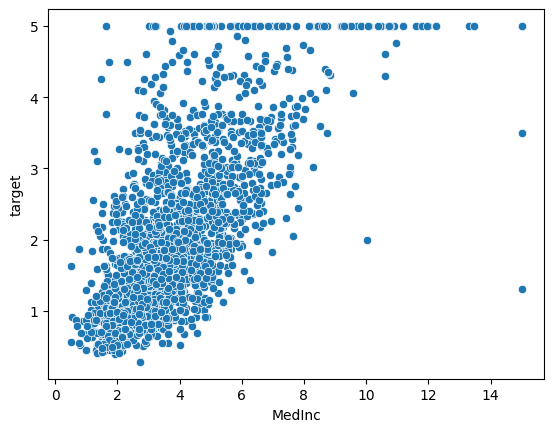

In [ ]:
import seaborn as sns


df_vis = df_spark.sample(False, 0.1).toPandas()

sns.scatterplot(x='MedInc', y='target', data=df_vis)
plt.show()
#

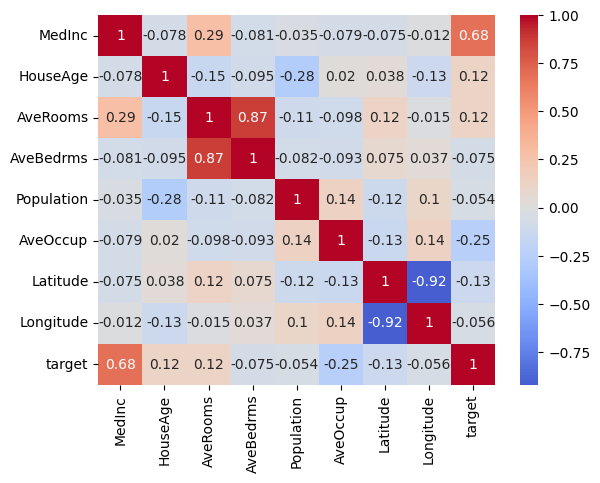

In [ ]:
correlation_matrix = df_vis.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.show()

In [ ]:
train_data, test_data = df_spark.randomSplit([0.8, 0.2], seed =42)

In [ ]:
assembler = VectorAssembler(inputCols=['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], outputCol='features')
train_data = assembler.transform(train_data)
test_data = assembler.transform(test_data)

train_data = train_data.select('features', 'target')
test_data = test_data.select('features', 'target')
#

In [ ]:
lr = LinearRegression(featuresCol='features', labelCol='target')
gbt = GBTRegressor(featuresCol='features', labelCol='target')

lr_model = lr.fit(train_data)
gbt_model = gbt.fit(train_data)


lr_predictions = lr_model.transform(test_data)
gbt_predictions = gbt_model.transform(test_data)

lr_evaluator = RegressionEvaluator(labelCol='target', predictionCol='prediction', metricName='rmse')
gbt_evaluator = RegressionEvaluator(labelCol='target', predictionCol='prediction', metricName='rmse')

lr_rmse = lr_evaluator.evaluate(lr_predictions)
gbt_rmse = gbt_evaluator.evaluate(gbt_predictions)

In [ ]:
print("RMSE Linear Regression: ", lr_rmse)
print("RMSE Gradient Boosted Trees: ", gbt_rmse)

RMSE Linear Regression:  0.733293906676871
RMSE Gradient Boosted Trees:  0.5743950425695393


In [ ]:
lr_evaluator = RegressionEvaluator(labelCol='target', predictionCol='prediction', metricName='r2')
gbt_evaluator = RegressionEvaluator(labelCol='target', predictionCol='prediction', metricName='r2')

lr_r2 = lr_evaluator.evaluate(lr_predictions)
gbt_r2 = gbt_evaluator.evaluate(gbt_predictions)


In [ ]:
print("R2 Linear Regression: ", lr_r2 *100)
print("R2 Gradient Boosted Trees: ", gbt_r2*100)

R2 Linear Regression:  58.63933868971052
R2 Gradient Boosted Trees:  74.62227496536163


In [ ]:
from pyspark.ml.classification import LogisticRegression

# Download the sample libsvm data
!mkdir -p data/mllib
!wget -nc -P data/mllib https://raw.githubusercontent.com/apache/spark/master/data/mllib/sample_libsvm_data.txt

# Load training data
training = spark.read.format("libsvm").load("data/mllib/sample_libsvm_data.txt")

lr = LogisticRegression(maxIter=10, regParam=0.3, elasticNetParam=0.8)

# Fit the model
lrModel = lr.fit(training)

# Print the coefficients and intercept for logistic regression
print("Coefficients: " + str(lrModel.coefficients))
print("Intercept: " + str(lrModel.intercept))

# We can also use the multinomial family for binary classification
mlr = LogisticRegression(maxIter=10, regParam=0.3, elasticNetParam=0.8, family="multinomial")

# Fit the model
mlrModel = mlr.fit(training)

# Print the coefficients and intercepts for logistic regression with multinomial family
print("Multinomial coefficients: " + str(mlrModel.coefficientMatrix))
print("Multinomial intercepts: " + str(mlrModel.interceptVector))

--2026-07-19 00:04:20--  https://raw.githubusercontent.com/apache/spark/master/data/mllib/sample_libsvm_data.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 104736 (102K) [text/plain]
Saving to: ‘data/mllib/sample_libsvm_data.txt’

sample_libsvm_data. 100%[===================>] 102.28K  --.-KB/s    in 0.008s  

2026-07-19 00:04:21 (12.2 MB/s) - ‘data/mllib/sample_libsvm_data.txt’ saved [104736/104736]

Coefficients: (692,[272,300,323,350,351,378,379,405,406,407,428,433,434,435,455,456,461,462,483,484,489,490,496,511,512,517,539,540,568],[-7.520689871384125e-05,-8.115773146847006e-05,3.814692771846427e-05,0.0003776490540424338,0.0003405148366194403,0.0005514455157343107,0.0004085386116096912,0.0004197467332749452,0.0008119171358670031,0.000502770837266875

In [ ]:
from pyspark.sql import SparkSession
from sklearn.datasets import load_breast_cancer
import pandas as pd
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier, LinearSVC, NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt

In [ ]:
spark = SparkSession.builder.appName("Breast Cancer Classification").getOrCreate()

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['label'] = data.target

spark_df = spark.createDataFrame(df)
spark_df.show()

+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+-----+
|mean radius|mean texture|mean perimeter|mean area|mean smoothness|mean compactness|mean concavity|mean concave points|mean symmetry|mean fractal dimension|radius error|texture error|perimeter error|area error|smoothness error|compactness error|concavity error|concave points error|symmetry error|fractal dimension error|worst radius|worst texture|worst perimeter|worst area|worst smoothness|worst compactness|worst concavity|worst concave points|worst symmetry|worst fractal dimension|label|
+-----------+-

In [ ]:
train_data, test_data = spark_df.randomSplit([0.8, 0.2], seed=42)

assembler = VectorAssembler(inputCols=data.feature_names, outputCol="features")
train_data = assembler.transform(train_data).select("features", "label")
test_data = assembler.transform(test_data).select("features", "label")


In [ ]:
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier, LinearSVC, NaiveBayes


models = [
    ("Logistic Regression", LogisticRegression(featuresCol="features", labelCol="label")),
    ("Decision Tree", DecisionTreeClassifier(featuresCol="features", labelCol="label")),
    ("Random Forest", RandomForestClassifier(featuresCol="features", labelCol="label")),
    ("Gradient-boosted Tree", GBTClassifier(featuresCol="features", labelCol="label")),
    ("Linear SVC", LinearSVC(featuresCol="features", labelCol="label")),
    ("Naive Bayes", NaiveBayes(featuresCol="features", labelCol="label"))
]

evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

best_acc = 0.0
best_model_name = ""

for name, model in models:
    model_fit = model.fit(train_data)
    predictions = model_fit.transform(test_data)
    accuracy = evaluator.evaluate(predictions)
    print(f"Accuracy for {name}: {accuracy: .2f}")
    if accuracy > best_acc:
        best_acc = accuracy
        best_model_name = name

print(f"Best model: {best_model_name} with accuracy: {best_acc: .2f}")

Accuracy for Logistic Regression:  0.94
Accuracy for Decision Tree:  0.89
Accuracy for Random Forest:  0.96
Accuracy for Gradient-boosted Tree:  0.91
Accuracy for Linear SVC:  0.95
Accuracy for Naive Bayes:  0.91
Best model: Random Forest with accuracy:  0.96


In [ ]:
# Matriz de confusión

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(test_data.select("label").toPandas(), predictions.select("prediction").toPandas())
cm

array([[24,  6],
       [ 3, 62]])

24 etiquetas predichas en 0 "benigno" y realmente eran 0 "benigno"

62 etiquetas predichas en 1 "maligno" y realmente eran 1 "maligno"

3  etiquetas predichas en 0 "benigno" y realmente eran 1 "maligno"

6 etiquetas predichas en 1 "maligno" y realmente eran 0 "benigno"

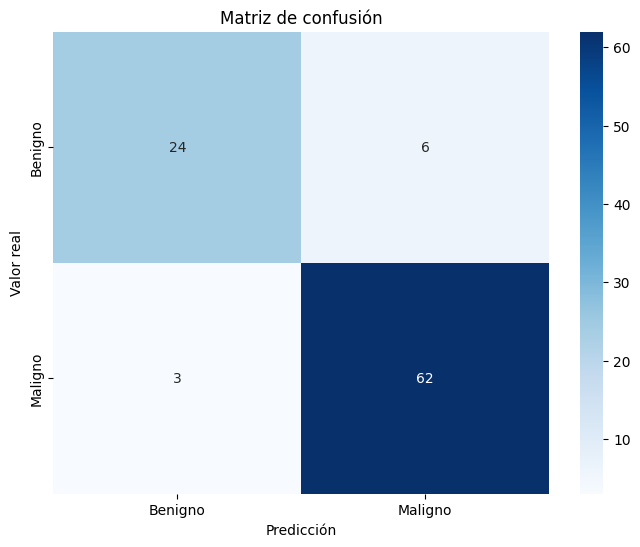

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión')
plt.show()

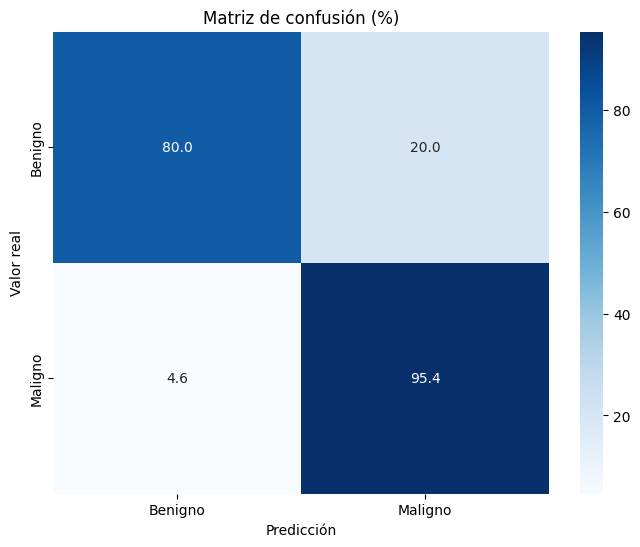

In [ ]:
import numpy as np


cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión (%)')
plt.show()